Step 1: Install Gemini SDK

In [1]:
!pip install -q google-generativeai pandas

Step 2: Configure Gemini API

In [4]:
import google.generativeai as genai

# Replace with your Gemini API key
API_KEY = "Your_Api_Name"

genai.configure(api_key=API_KEY)

model = genai.GenerativeModel("gemini-2.5-flash")

Step 3: Upload CSV Dataset

In [5]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)

print("Dataset Shape:", df.shape)
df.head()

Saving walmart_clean.xls to walmart_clean.xls
Dataset Shape: (6435, 11)


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Week
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2010,2,5
1,10,2010-02-05,2193048.75,0,54.34,2.962,126.442065,9.765,2010,2,5
2,37,2010-02-05,536006.73,0,45.97,2.572,209.852966,8.554,2010,2,5
3,17,2010-02-05,789036.02,0,23.11,2.666,126.442065,6.548,2010,2,5
4,30,2010-02-05,465108.52,0,39.05,2.572,210.752605,8.324,2010,2,5


Step 4: Dataset Summary

In [10]:
print(df.info())
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
 8   Year          6435 non-null   int64  
 9   Month         6435 non-null   int64  
 10  Week          6435 non-null   int64  
dtypes: float64(5), int64(5), object(1)
memory usage: 553.1+ KB
None
Dataset Shape: (6435, 11)

Columns:
['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Year', 'Month', 'Week']

Data Types:
Store             int64
Date             object
Weekly_Sales    float64
Holiday_Flag     

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Week
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151,2010.965035,6.447552,25.818182
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885,0.797019,3.238308,14.129201
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000,2010.000000,1.000000,1.000000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000,2010.000000,4.000000,14.000000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000,2011.000000,6.000000,26.000000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000,2012.000000,9.000000,38.000000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000,2012.000000,12.000000,52.000000


Step 5: Visualizations ← Add after EDA

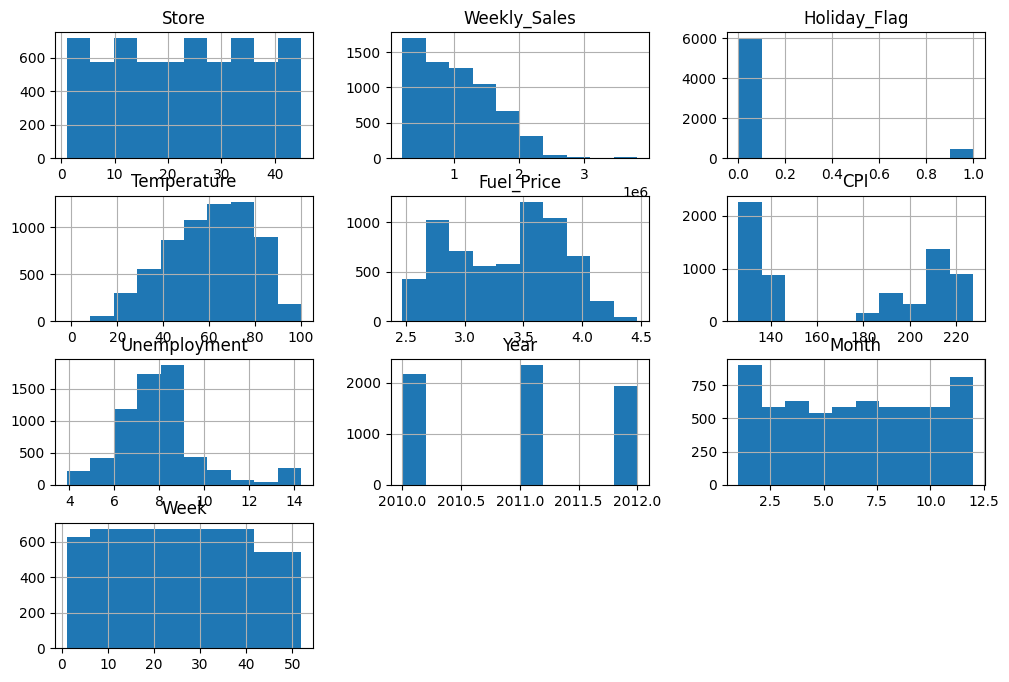

In [11]:
import matplotlib.pyplot as plt

df.hist(figsize=(12,8))
plt.show()

Step 6 :Correlation Heatmap

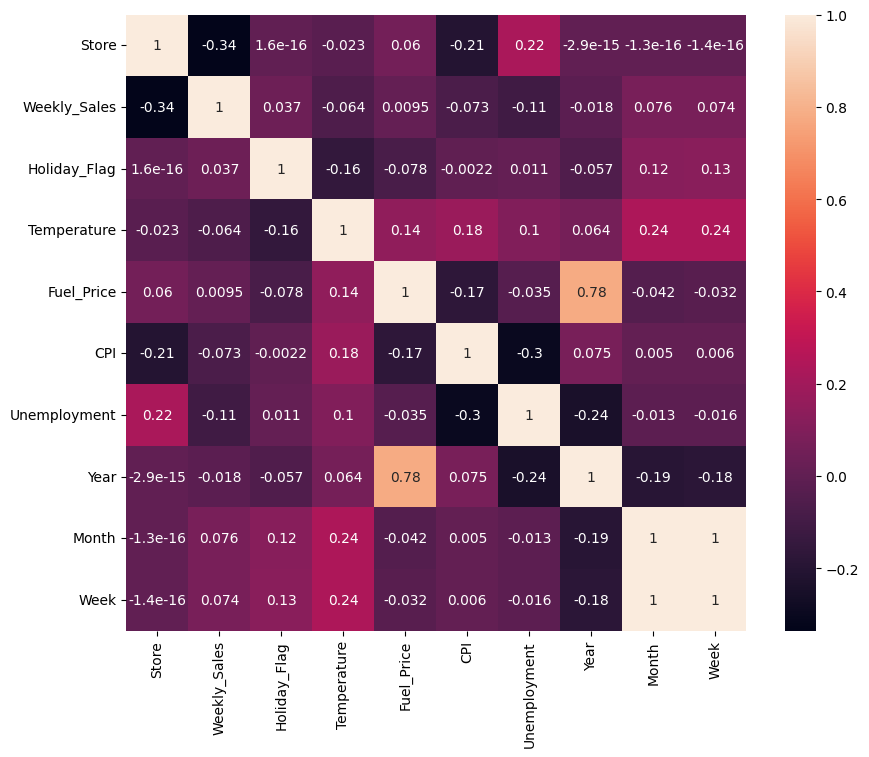

In [12]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

Step 5: Ask Questions About Your Data

In [7]:
question = input("Ask a question about your dataset: ")

sample_data = df.head(20).to_string()

prompt = f"""
You are a professional Data Analyst.

Dataset Columns:
{list(df.columns)}

Dataset Shape:
{df.shape}

Sample Data:
{sample_data}

Question:
{question}

Provide a detailed analysis and insights.
"""

response = model.generate_content(prompt)

print(response.text)

Ask a question about your dataset: holiday flag impact
As a professional Data Analyst, let's dive into the impact of the `Holiday_Flag` on `Weekly_Sales` using the provided dataset.

**Objective:** To determine if weeks marked as holidays (`Holiday_Flag = 1`) exhibit a different pattern in `Weekly_Sales` compared to non-holiday weeks (`Holiday_Flag = 0`).

---

### **1. Initial Overview & Data Distribution**

First, let's understand the distribution of our `Holiday_Flag`.

```python
import pandas as pd
from scipy import stats
import numpy as np

# Recreating the dataframe based on the provided structure and sample data
data = {
    'Store': [1, 10, 37, 17, 30, 25, 22, 23, 24, 19, 21, 26, 39, 8, 32, 15, 34, 13, 38, 9],
    'Date': ['2010-02-05'] * 20,
    'Weekly_Sales': [1643690.90, 2193048.75, 536006.73, 789036.02, 465108.52, 677231.63, 1033017.37, 1364721.58, 1388725.63, 1507637.17, 798593.88, 1034119.21, 1230596.80, 1004137.09, 1087616.19, 652122.44, 956228.96, 1967220.53, 358496.14

Step 6: Auto-Generate Insights

In [8]:
sample_data = df.head(30).to_string()

prompt = f"""
Analyze this dataset and provide:

1. Key Insights
2. Trends
3. Potential Business Recommendations
4. Data Quality Issues
5. Interesting Patterns

Dataset Sample:

{sample_data}
"""

response = model.generate_content(prompt)

print(response.text)

ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 4093.72ms


Based on the provided dataset sample, here's an analysis:

---

## Dataset Analysis

**Context:** The provided sample represents a snapshot of sales and related economic/environmental factors across various stores on a single specific date: 2010-02-05.

---

### 1. Key Insights

1.  **Significant Sales Variance Across Stores:** Even on the same day, Weekly Sales vary drastically between stores. For example, Store 38 recorded sales of \$358,496.14, while Store 20 achieved \$2,401,395.47, highlighting a massive difference in store performance or size.
2.  **Store-Specific Environmental/Economic Factors:** Temperature, Fuel Price, CPI, and Unemployment are not uniform across all stores on this single date. This suggests that these metrics are either localized (e.g., store's geographical location) or the data aggregates regional variations assigned to each store.
3.  **No Holiday Impact in Sample:** The `Holiday_Flag` is `0` for all records in the sample, meaning this specific date (2010-0